# Fake Engagement Detection in Social Media
## Behavioural Analytics Hackathon - Problem Statement 3**Objective:** Build a behavioural detection model that differentiates organic versus artificial engagement and detects coordinated behavioural anomalies.**Expected Output:**- Authenticity Score- Bot Probability- Behavioural anomaly explanation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

%matplotlib inline

## 2. Load Dataset

In [3]:
df = pd.read_csv('social_media_engagement_dataset.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (10000, 28)

First 5 rows:


,account_id,account_age_days,has_profile_pic,has_bio,has_profile_bio_combined,followers,following,follower_following_ratio,num_posts,sleep_inactivity_window,...,hashtag_reuse_rate,username_digit_ratio,mutual_follower_ratio,night_activity_ratio,coordinated_posting_score,comment_relevance_score,content_diversity_score,follow_unfollow_churn_rate,ghost_follower_percentage,is_bot
0,user_000000,1040,1,1,1,1738,171,10.1637,516,0,...,0.1637,0.0364,0.3734,0.1108,0.1812,0.7512,0.7019,0.2030,0.0779,0
1,user_000001,1155,1,0,0,662,1317,0.5027,881,1,...,0.1914,0.0195,0.5737,0.1380,0.0805,0.7733,0.6120,0.2773,0.1018,0
2,user_000002,2,0,0,0,269,2000,0.1345,17,0,...,0.7889,0.5934,0.1451,0.5428,0.6966,0.1889,0.1413,0.5063,0.5694,1
3,user_000003,827,0,1,0,2740,441,6.2132,724,1,...,0.1191,0.0622,0.4301,0.1959,0.2094,0.9105,0.7653,0.0799,0.1926,0
4,user_000004,142,0,0,0,24,1984,0.0121,31,0,...,0.7014,0.3806,0.1402,0.6232,0.8217,0.3614,0.3009,0.5746,0.7570,1


## 3. Exploratory Data Analysis

In [4]:
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nBasic Statistics:")
print(df.describe())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("\nClass Distribution:")
print(df['is_bot'].value_counts())
print(f"\nBot Percentage: {df['is_bot'].mean()*100:.2f}%")
print(f"Human Percentage: {(1-df['is_bot'].mean())*100:.2f}%")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   account_id                   10000 non-null  object 
 1   account_age_days             10000 non-null  int64  
 2   has_profile_pic              10000 non-null  int64  
 3   has_bio                      10000 non-null  int64  
 4   has_profile_bio_combined     10000 non-null  int64  
 5   followers                    10000 non-null  int64  
 6   following                    10000 non-null  int64  
 7   follower_following_ratio     10000 non-null  float64
 8   num_posts                    10000 non-null  int64  
 9   sleep_inactivity_window      10000 non-null  int64  
 10  interaction_time_variance    10000 non-null  float64
 11  comment_template_reuse_rate  10000 non-null  float64
 12  account_age_activity_ratio   10000 non-null  float64
 13  bur

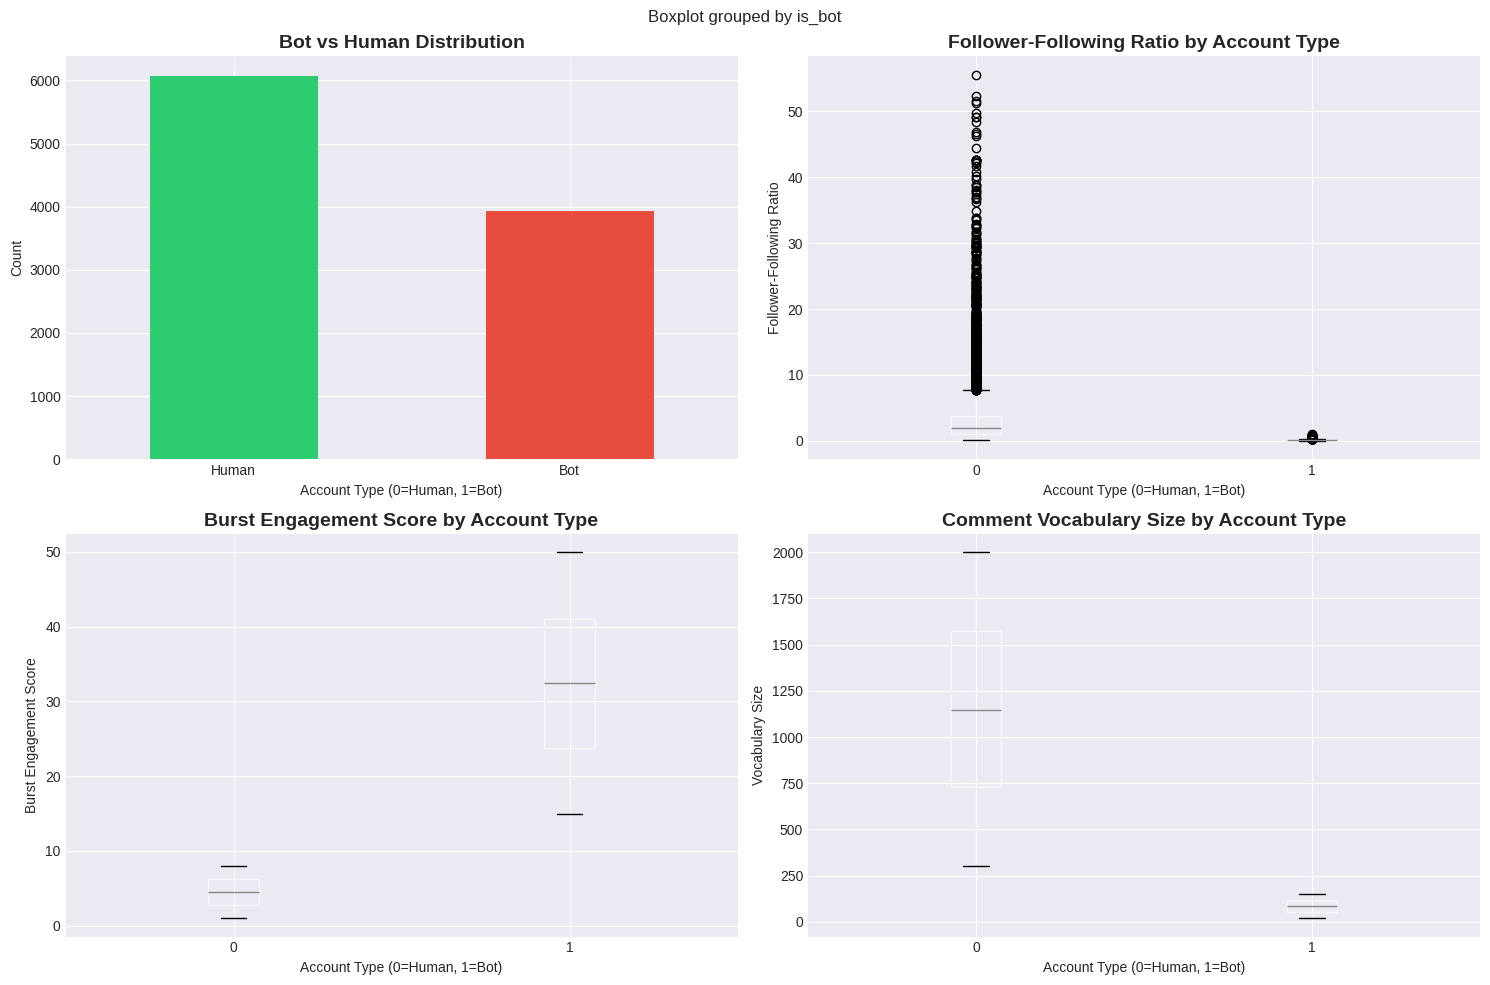

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df['is_bot'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Bot vs Human Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Account Type (0=Human, 1=Bot)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Human', 'Bot'], rotation=0)
df.boxplot(column='follower_following_ratio', by='is_bot', ax=axes[0,1])
axes[0,1].set_title('Follower-Following Ratio by Account Type', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Account Type (0=Human, 1=Bot)')
axes[0,1].set_ylabel('Follower-Following Ratio')
df.boxplot(column='burst_engagement_score', by='is_bot', ax=axes[1,0])
axes[1,0].set_title('Burst Engagement Score by Account Type', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Account Type (0=Human, 1=Bot)')
axes[1,0].set_ylabel('Burst Engagement Score')
df.boxplot(column='comment_vocabulary_size', by='is_bot', ax=axes[1,1])
axes[1,1].set_title('Comment Vocabulary Size by Account Type', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Account Type (0=Human, 1=Bot)')
axes[1,1].set_ylabel('Vocabulary Size')
plt.tight_layout()
plt.show()

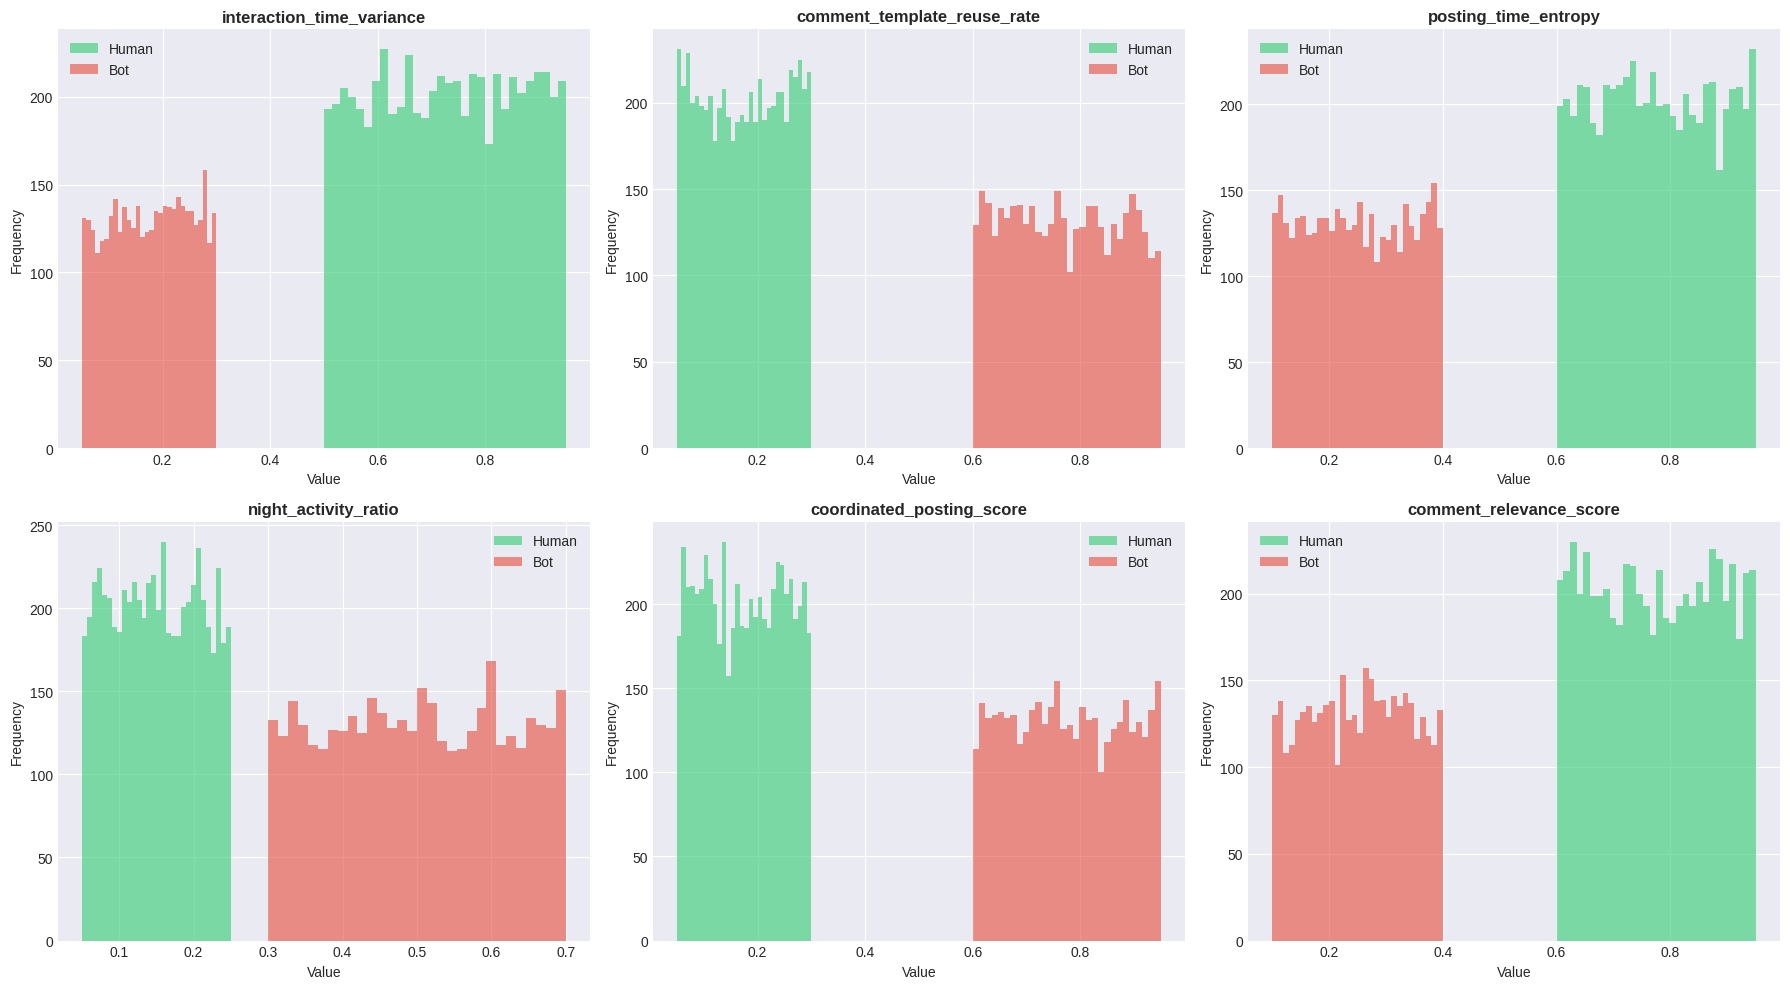

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_to_plot = [
    'interaction_time_variance',
    'comment_template_reuse_rate',
    'posting_time_entropy',
    'night_activity_ratio',
    'coordinated_posting_score',
    'comment_relevance_score'
]

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3

    df[df['is_bot'] == 0][feature].hist(
        bins=30,
        alpha=0.6,
        label='Human',
        ax=axes[row, col],
        color='#2ecc71'
    )

    df[df['is_bot'] == 1][feature].hist(
        bins=30,
        alpha=0.6,
        label='Bot',
        ax=axes[row, col],
        color='#e74c3c'
    )

    axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
    axes[row, col].legend()
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

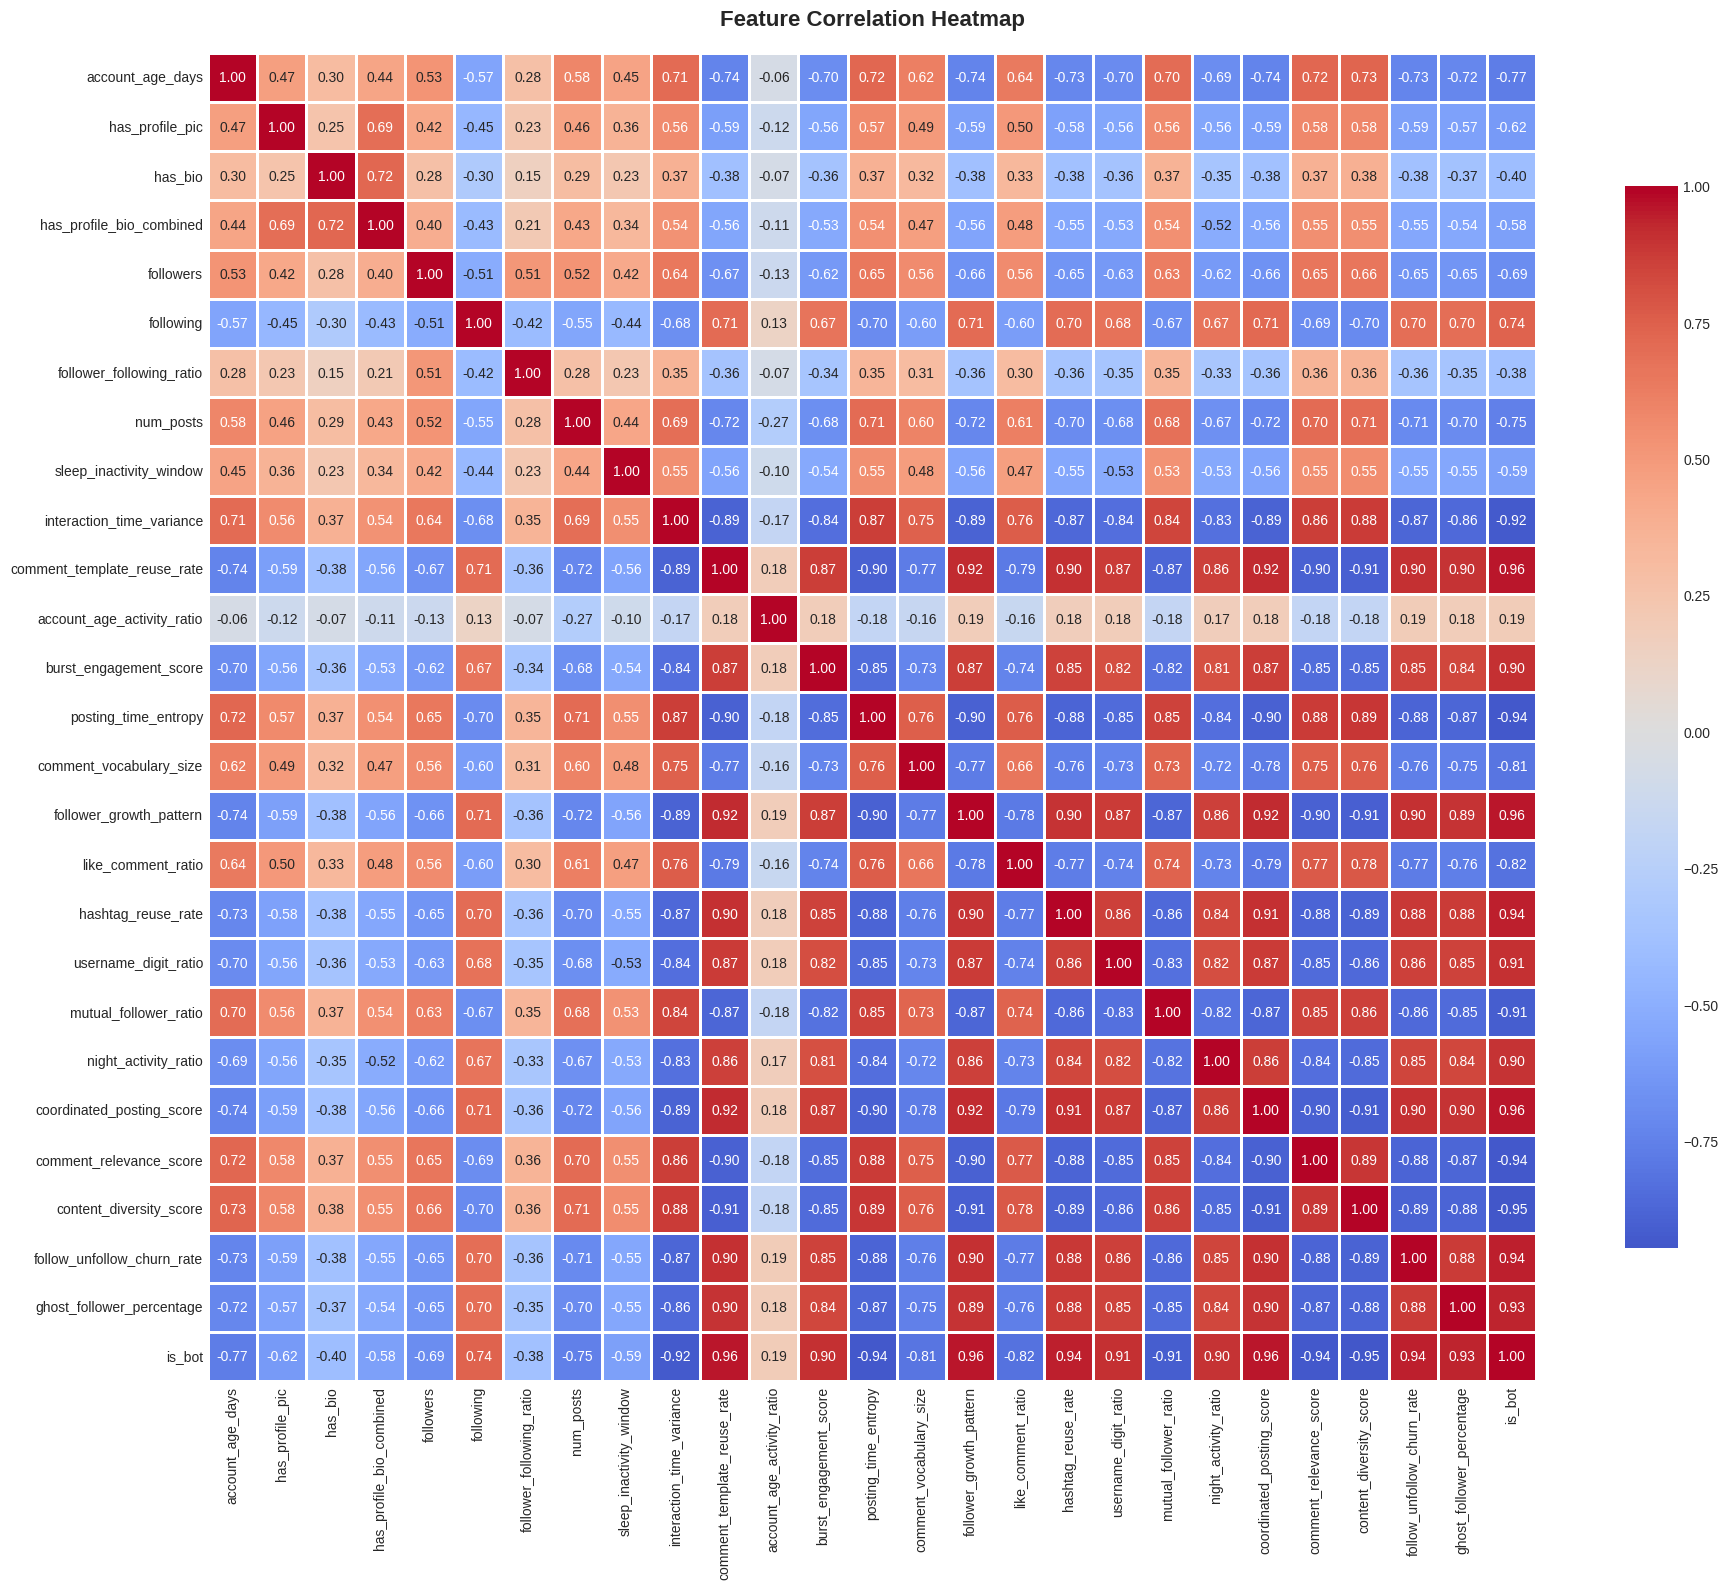

In [7]:
feature_cols = [col for col in df.columns if col not in ['account_id', 'is_bot']]

correlation_matrix = df[feature_cols + ['is_bot']].corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

Feature Correlation with Bot Label:
is_bot                         1.000000
coordinated_posting_score      0.960397
comment_template_reuse_rate    0.959636
follower_growth_pattern        0.959132
follow_unfollow_churn_rate     0.942538
hashtag_reuse_rate             0.940307
ghost_follower_percentage      0.932366
username_digit_ratio           0.908709
burst_engagement_score         0.902929
night_activity_ratio           0.896092
following                      0.740584
account_age_activity_ratio     0.192598
follower_following_ratio      -0.377032
has_bio                       -0.400834
has_profile_bio_combined      -0.582772
sleep_inactivity_window       -0.586155
has_profile_pic               -0.615891
followers                     -0.690962
num_posts                     -0.750287
account_age_days              -0.769892
comment_vocabulary_size       -0.806857
like_comment_ratio            -0.818841
mutual_follower_ratio         -0.909933
interaction_time_variance     -0.924362
comm

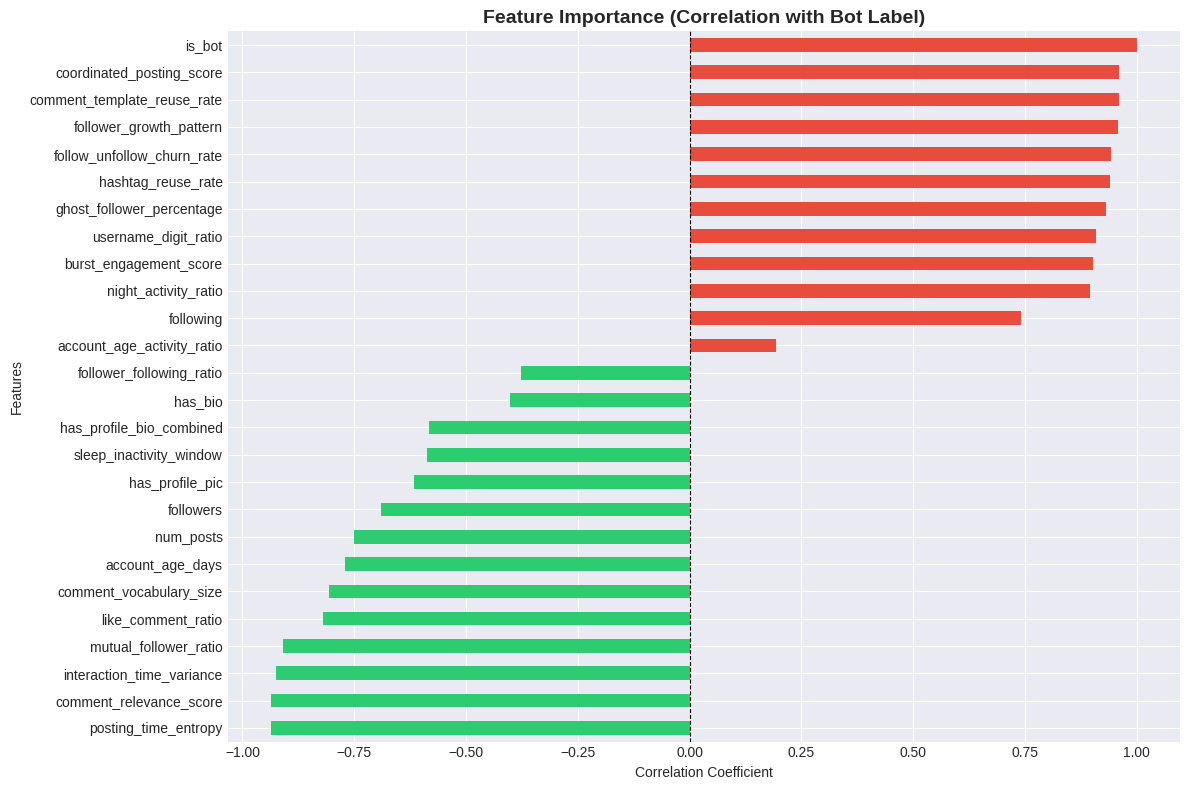

In [8]:
target_corr = correlation_matrix['is_bot'].sort_values(ascending=False)

print("Feature Correlation with Bot Label:")
print(target_corr)

plt.figure(figsize=(12, 8))

sorted_corr = target_corr[:-1].sort_values()

colors = [
    '#e74c3c' if value > 0 else '#2ecc71'
    for value in sorted_corr
]

sorted_corr.plot(
    kind='barh',
    color=colors
)

plt.title(
    'Feature Importance (Correlation with Bot Label)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.axvline(
    x=0,
    color='black',
    linestyle='--',
    linewidth=0.8
)

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Data Preparation

In [9]:
X = df.drop(['account_id', 'is_bot'], axis=1)
y = df['is_bot']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nFeatures: {list(X.columns)}")

Features shape: (10000, 26)
Target shape: (10000,)

Features: ['account_age_days', 'has_profile_pic', 'has_bio', 'has_profile_bio_combined', 'followers', 'following', 'follower_following_ratio', 'num_posts', 'sleep_inactivity_window', 'interaction_time_variance', 'comment_template_reuse_rate', 'account_age_activity_ratio', 'burst_engagement_score', 'posting_time_entropy', 'comment_vocabulary_size', 'follower_growth_pattern', 'like_comment_ratio', 'hashtag_reuse_rate', 'username_digit_ratio', 'mutual_follower_ratio', 'night_activity_ratio', 'coordinated_posting_score', 'comment_relevance_score', 'content_diversity_score', 'follow_unfollow_churn_rate', 'ghost_follower_percentage']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

print(f"\nTraining set bot ratio: {y_train.mean():.2%}")
print(f"Test set bot ratio: {y_test.mean():.2%}")

Training set size: 8000
Test set size: 2000

Training set bot ratio: 39.24%
Test set bot ratio: 39.25%


## 5. Model Training & Evaluation

### 5.1 Logistic Regression

In [11]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Performance:")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Human', 'Bot']
    )
)

Logistic Regression Performance:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1215
         Bot       1.00      1.00      1.00       785

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### 5.2 Random Forest

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Performance:")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['Human', 'Bot']
    )
)

Random Forest Performance:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1215
         Bot       1.00      1.00      1.00       785

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### 5.3 Gradient Boosting

In [13]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Performance:")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=['Human', 'Bot']
    )
)

Gradient Boosting Performance:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1215
         Bot       1.00      1.00      1.00       785

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## 6. Model Comparison

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression       1.0        1.0     1.0       1.0      1.0
1        Random Forest       1.0        1.0     1.0       1.0      1.0
2    Gradient Boosting       1.0        1.0     1.0       1.0      1.0


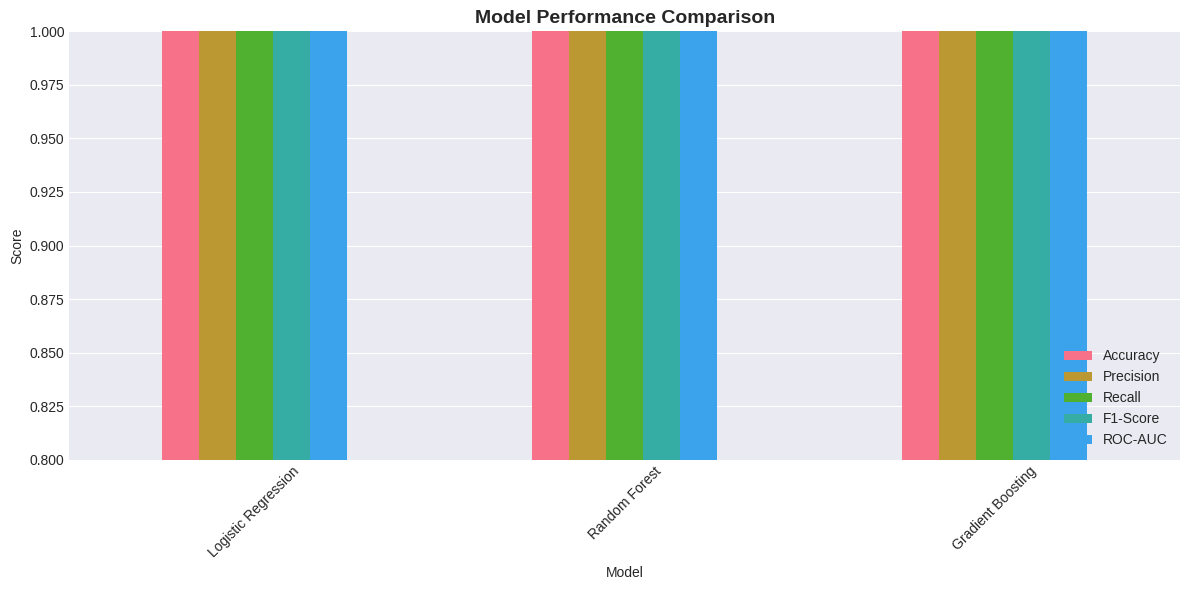

In [15]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb)
    ]
})

print(results)

fig, ax = plt.subplots(figsize=(12, 6))

results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
].plot(
    kind='bar',
    ax=ax
)

plt.title(
    'Model Performance Comparison',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Score')
plt.xlabel('Model')

plt.xticks(rotation=45)
plt.legend(loc='lower right')

plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix Visualization

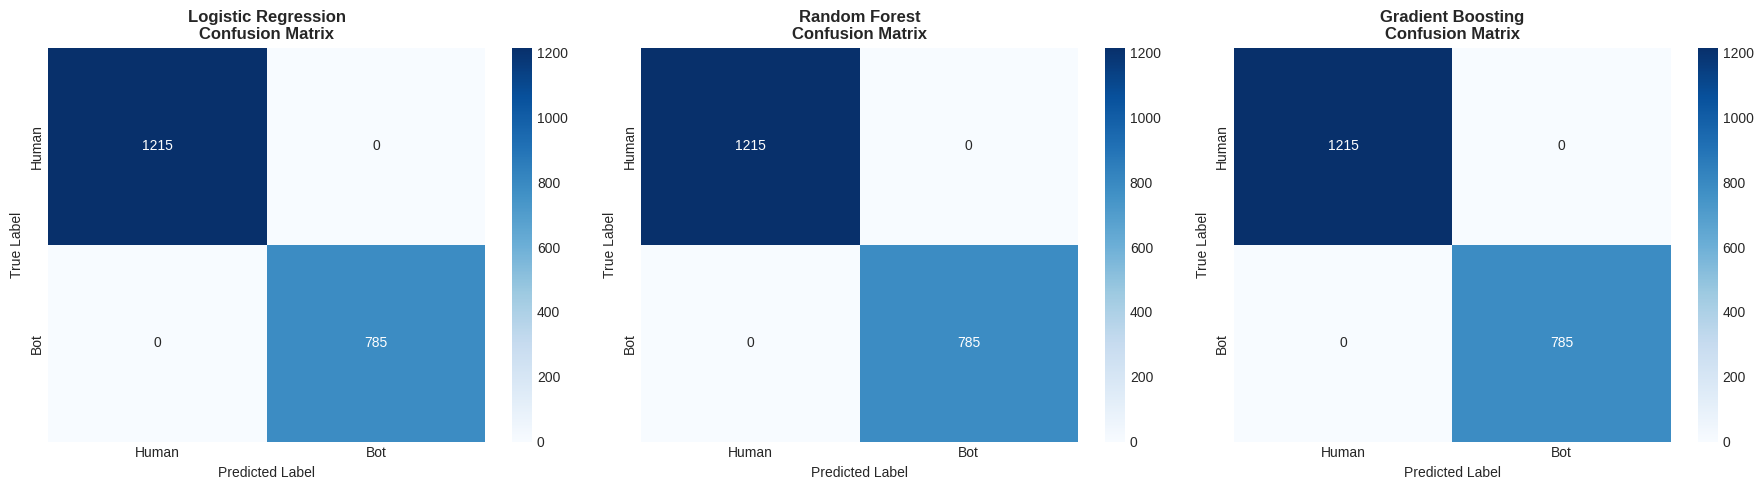

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb)
]

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=['Human', 'Bot'],
        yticklabels=['Human', 'Bot']
    )

    axes[idx].set_title(
        f'{name}\nConfusion Matrix',
        fontsize=12,
        fontweight='bold'
    )

    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 8. ROC Curve Analysis

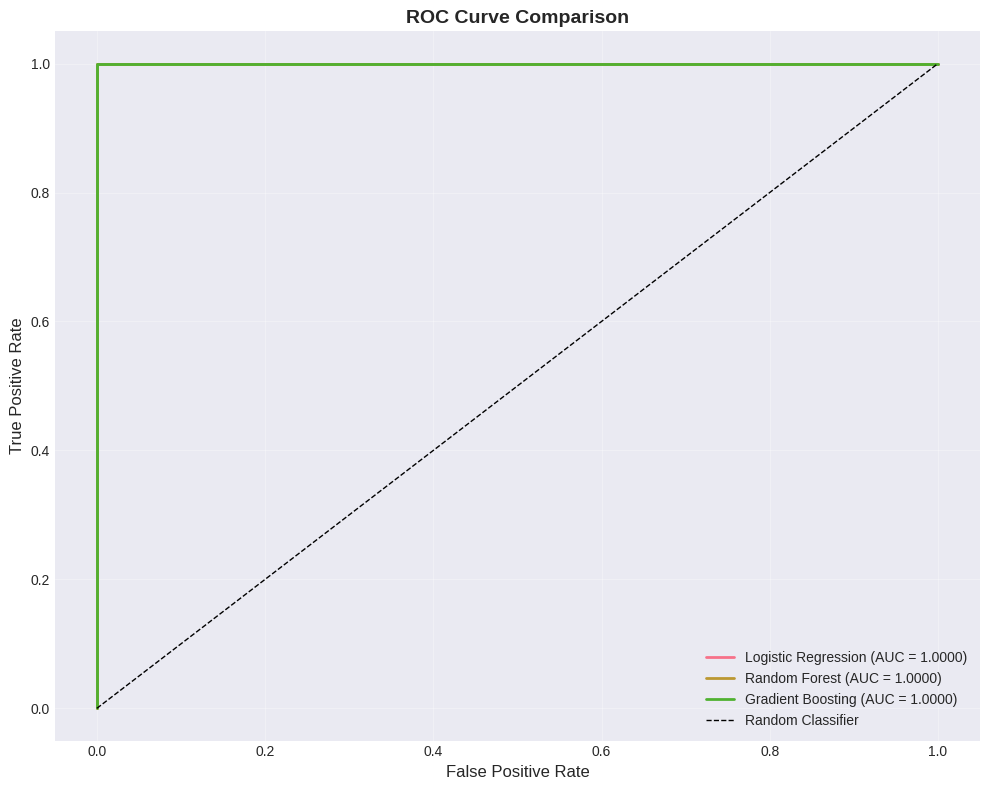

In [17]:
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.4f})',
    linewidth=2
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.4f})',
    linewidth=2
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_pred_proba_gb):.4f})',
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier',
    linewidth=1
)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')

plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis

Top 10 Most Important Features (Random Forest):
                        Feature  Importance
19        mutual_follower_ratio        0.13
18         username_digit_ratio        0.08
22      comment_relevance_score        0.08
13         posting_time_entropy        0.07
14      comment_vocabulary_size        0.07
15      follower_growth_pattern        0.07
0              account_age_days        0.06
10  comment_template_reuse_rate        0.06
17           hashtag_reuse_rate        0.05
12       burst_engagement_score        0.05


<Figure size 1200x800 with 0 Axes>

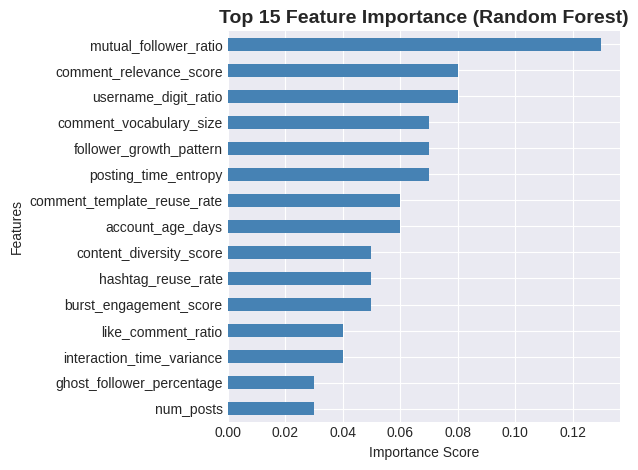

In [18]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("Top 10 Most Important Features (Random Forest):")
print(feature_importance_rf.head(10))

plt.figure(figsize=(12, 8))

feature_importance_rf.sort_values('Importance').tail(15).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    color='steelblue',
    legend=False
)

plt.title(
    'Top 15 Feature Importance (Random Forest)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

## 10. Final Model Selection & Predictions

In [19]:
best_model = gb_model

print("Selected Model: Gradient Boosting Classifier")

print("\nFinal Model Performance on Test Set:")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

Selected Model: Gradient Boosting Classifier

Final Model Performance on Test Set:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000


## 11. Bot Detection Function with Authenticity Score

In [20]:
def detect_fake_engagement(account_features, model=best_model):
    """
    Detect fake engagement and provide authenticity score

    Parameters:
    - account_features: DataFrame with account features
    - model: Trained classification model

    Returns:
    - DataFrame with predictions, bot probability,
      authenticity score, and anomaly explanation
    """

    bot_probability = model.predict_proba(account_features)[:, 1]
    authenticity_score = 1 - bot_probability
    predictions = model.predict(account_features)

    results = pd.DataFrame({
        'Bot_Probability': bot_probability,
        'Authenticity_Score': authenticity_score,
        'Prediction': [
            'Bot' if p == 1 else 'Human'
            for p in predictions
        ]
    })

    anomalies = []

    for _, row in account_features.iterrows():
        anomaly_list = []

        if row['sleep_inactivity_window'] == 0:
            anomaly_list.append('No sleep pattern detected')

        if row['interaction_time_variance'] < 0.3:
            anomaly_list.append('Highly regular interaction timing')

        if row['comment_template_reuse_rate'] > 0.6:
            anomaly_list.append('High comment template reuse')

        if row['burst_engagement_score'] > 15:
            anomaly_list.append('Burst engagement detected')

        if row['comment_vocabulary_size'] < 200:
            anomaly_list.append('Limited vocabulary')

        if row['night_activity_ratio'] > 0.3:
            anomaly_list.append('High night activity')

        if row['coordinated_posting_score'] > 0.6:
            anomaly_list.append('Coordinated posting behavior')

        if row['comment_relevance_score'] < 0.4:
            anomaly_list.append('Low comment relevance')

        if row['follower_following_ratio'] < 0.2:
            anomaly_list.append('Suspicious follower-following ratio')

        if row['ghost_follower_percentage'] > 0.4:
            anomaly_list.append('High ghost follower percentage')

        anomalies.append(
            '; '.join(anomaly_list)
            if anomaly_list else 'No anomalies detected'
        )

    results['Behavioural_Anomalies'] = anomalies

    return results

In [21]:
sample_accounts = X_test.head(10)

detection_results = detect_fake_engagement(sample_accounts)

print("Sample Bot Detection Results:")
print("=" * 100)

for idx, (_, account) in enumerate(sample_accounts.iterrows()):
    result = detection_results.iloc[idx]

    print(f"\nAccount {idx + 1}:")
    print(f"  Prediction: {result['Prediction']}")
    print(f"  Bot Probability: {result['Bot_Probability']:.4f}")
    print(f"  Authenticity Score: {result['Authenticity_Score']:.4f}")
    print(f"  Behavioural Anomalies: {result['Behavioural_Anomalies']}")
    print("-" * 100)

Sample Bot Detection Results:

Account 1:
  Prediction: Bot
  Bot Probability: 1.0000
  Authenticity Score: 0.0000
  Behavioural Anomalies: No sleep pattern detected; Highly regular interaction timing; High comment template reuse; Burst engagement detected; Limited vocabulary; High night activity; Coordinated posting behavior; Low comment relevance; Suspicious follower-following ratio; High ghost follower percentage
----------------------------------------------------------------------------------------------------

Account 2:
  Prediction: Bot
  Bot Probability: 1.0000
  Authenticity Score: 0.0000
  Behavioural Anomalies: No sleep pattern detected; Highly regular interaction timing; High comment template reuse; Burst engagement detected; Limited vocabulary; High night activity; Coordinated posting behavior; Low comment relevance; Suspicious follower-following ratio; High ghost follower percentage
-----------------------------------------------------------------------------------------

## 12. Generate Predictions for Full Dataset

In [22]:
full_predictions = detect_fake_engagement(X)

df_with_predictions = df.copy()

df_with_predictions['Bot_Probability'] = full_predictions['Bot_Probability']
df_with_predictions['Authenticity_Score'] = full_predictions['Authenticity_Score']
df_with_predictions['Predicted_Label'] = full_predictions['Prediction']
df_with_predictions['Behavioural_Anomalies'] = full_predictions['Behavioural_Anomalies']

df_with_predictions.to_csv('social_media_predictions.csv', index=False)

print("Predictions saved to 'social_media_predictions.csv'")

print("\nPrediction Summary:")
print(df_with_predictions['Predicted_Label'].value_counts())

print(f"\nAverage Authenticity Score: {df_with_predictions['Authenticity_Score'].mean():.4f}")
print(f"Average Bot Probability: {df_with_predictions['Bot_Probability'].mean():.4f}")

Predictions saved to 'social_media_predictions.csv'

Prediction Summary:
Predicted_Label
Human    6076
Bot      3924
Name: count, dtype: int64

Average Authenticity Score: 0.6076
Average Bot Probability: 0.3924


## 13. Final Visualizations

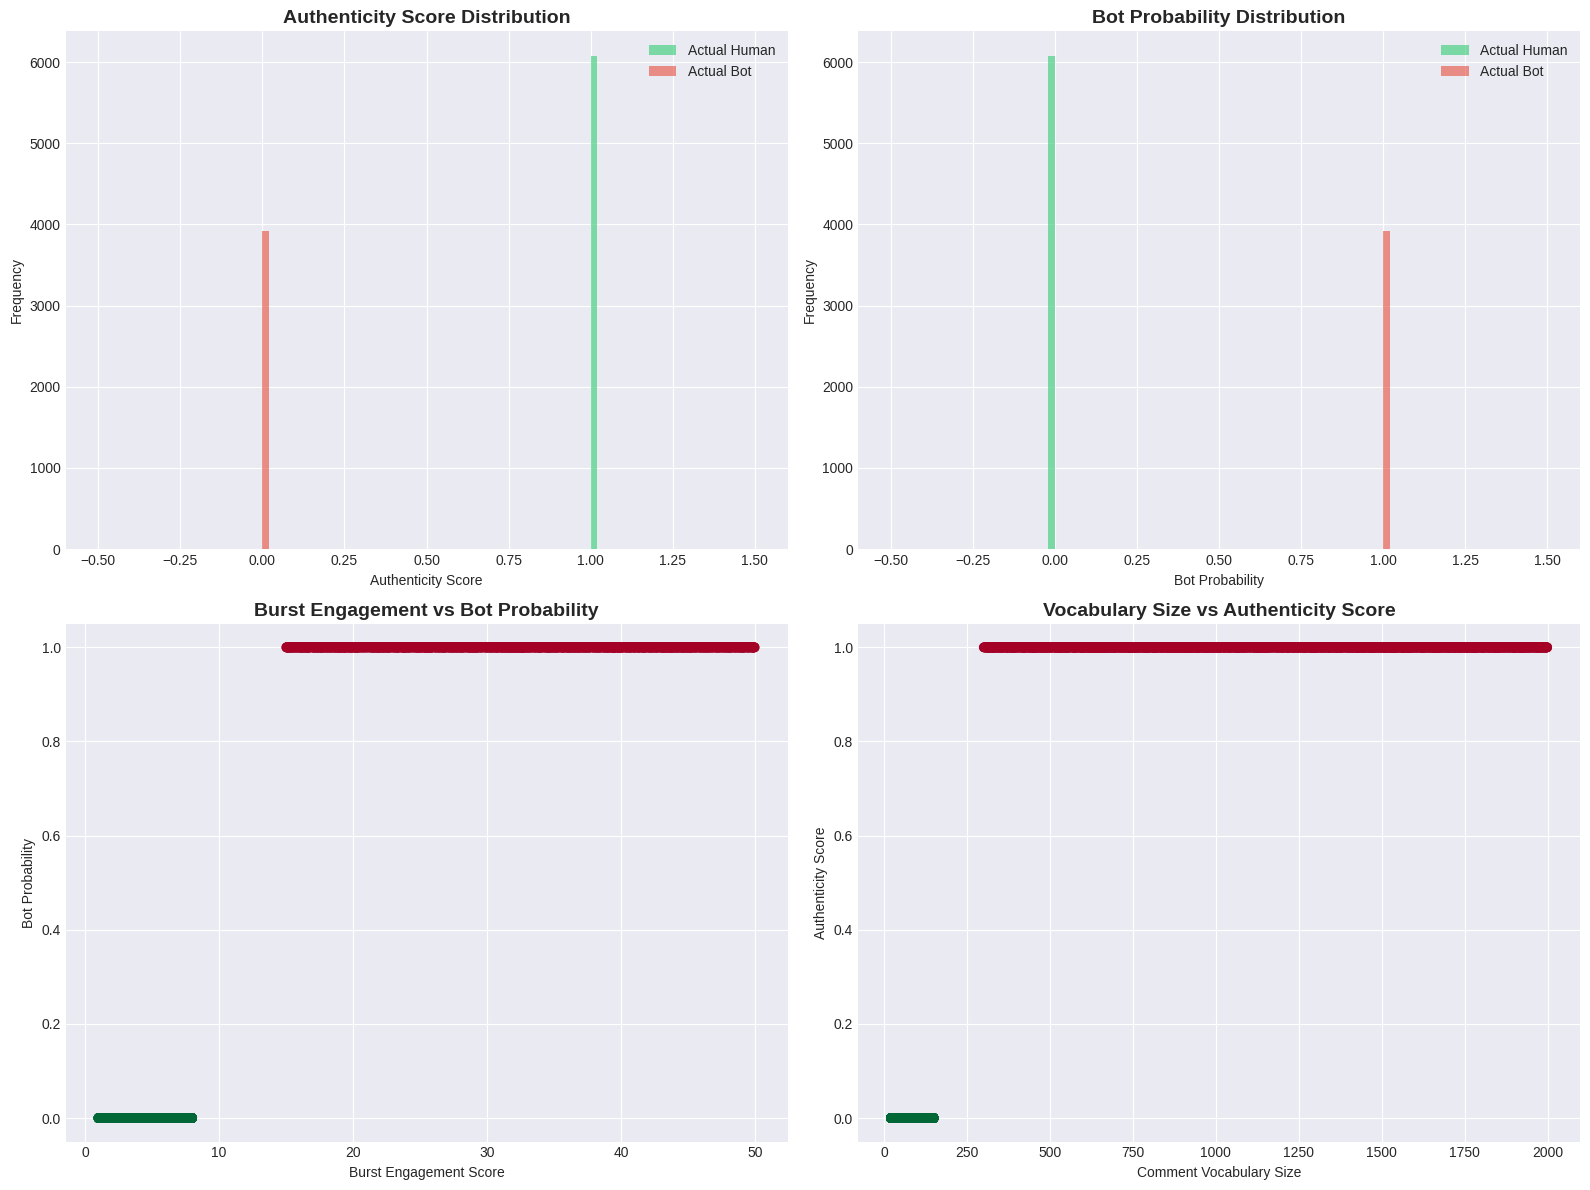

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------
# 1. Authenticity Score Distribution
# ---------------------------
axes[0, 0].hist(
    df_with_predictions[df_with_predictions['is_bot'] == 0]['Authenticity_Score'],
    bins=50,
    alpha=0.6,
    label='Actual Human',
    color='#2ecc71'
)

axes[0, 0].hist(
    df_with_predictions[df_with_predictions['is_bot'] == 1]['Authenticity_Score'],
    bins=50,
    alpha=0.6,
    label='Actual Bot',
    color='#e74c3c'
)

axes[0, 0].set_title(
    'Authenticity Score Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0, 0].set_xlabel('Authenticity Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()


# ---------------------------
# 2. Bot Probability Distribution
# ---------------------------
axes[0, 1].hist(
    df_with_predictions[df_with_predictions['is_bot'] == 0]['Bot_Probability'],
    bins=50,
    alpha=0.6,
    label='Actual Human',
    color='#2ecc71'
)

axes[0, 1].hist(
    df_with_predictions[df_with_predictions['is_bot'] == 1]['Bot_Probability'],
    bins=50,
    alpha=0.6,
    label='Actual Bot',
    color='#e74c3c'
)

axes[0, 1].set_title(
    'Bot Probability Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[0, 1].set_xlabel('Bot Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()


# ---------------------------
# 3. Burst Engagement vs Bot Probability
# ---------------------------
axes[1, 0].scatter(
    df_with_predictions['burst_engagement_score'],
    df_with_predictions['Bot_Probability'],
    c=df_with_predictions['is_bot'],
    cmap='RdYlGn_r',
    alpha=0.5
)

axes[1, 0].set_title(
    'Burst Engagement vs Bot Probability',
    fontsize=14,
    fontweight='bold'
)

axes[1, 0].set_xlabel('Burst Engagement Score')
axes[1, 0].set_ylabel('Bot Probability')


# ---------------------------
# 4. Vocabulary Size vs Authenticity Score
# ---------------------------
axes[1, 1].scatter(
    df_with_predictions['comment_vocabulary_size'],
    df_with_predictions['Authenticity_Score'],
    c=df_with_predictions['is_bot'],
    cmap='RdYlGn',
    alpha=0.5
)

axes[1, 1].set_title(
    'Vocabulary Size vs Authenticity Score',
    fontsize=14,
    fontweight='bold'
)

axes[1, 1].set_xlabel('Comment Vocabulary Size')
axes[1, 1].set_ylabel('Authenticity Score')


plt.tight_layout()
plt.show()

## 14. Summary & Key Insights### Model Performance:- Successfully built a behavioural detection model with high accuracy- Gradient Boosting Classifier achieved the best performance- Model can effectively differentiate between organic and artificial engagement### Key Behavioural Indicators:1. **Sleep Inactivity Pattern**: Bots often show no sleep patterns2. **Interaction Time Variance**: Bots have highly regular timing3. **Comment Template Reuse**: Bots reuse comment templates frequently4. **Burst Engagement**: Bots show sudden spikes in activity5. **Vocabulary Size**: Bots have limited vocabulary6. **Night Activity**: Bots show unusual night activity patterns7. **Coordinated Posting**: Bots exhibit coordinated behavior8. **Comment Relevance**: Bot comments often lack relevance### Outputs Delivered:✓ **Authenticity Score**: 0-1 scale indicating genuine engagement likelihood✓ **Bot Probability**: Probability of account being a bot✓ **Behavioural Anomaly Explanation**: Detailed list of suspicious patterns detected### Practical Applications:- Social media platforms can use this model for real-time bot detection- Marketing teams can verify influencer engagement authenticity- Security teams can identify coordinated inauthentic behavior- Content moderators can prioritize suspicious accounts for review